<a href="https://colab.research.google.com/github/laurinecharbonnier/trustpilot/blob/main/Trustpilot_Top2vec_Mod%C3%A9lisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librairies nécessaires
import os
import pickle
!pip install fasttext
import fasttext
import re
!pip install --upgrade top2vec gensim
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.fasttext import load_facebook_model
from top2vec import Top2Vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498208 sha256=295dbfcf7180fdecbd834fba2fde2e869f94b71416dc3cdc7f58b8bf434d401c
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:75: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

project_path = 'drive/MyDrive/TrustPilot/'
file_name = 'dataset_final.pkl'

# chargement des données
with open(os.path.join(project_path, file_name), 'rb') as f:
    df = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# préparation des documents pour les modéle
docs = df["clean_comment"].tolist()

In [ ]:
# création du modéle Top2Vec
model = Top2Vec(
    documents=docs,
    embedding_model='distiluse-base-multilingual-cased',  # or 'doc2vec' (smaller, faster)
    speed='learn',
    workers=4
)

2025-11-02 21:22:08,631 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-11-02 21:22:12,499 - top2vec - INFO - Downloading distiluse-base-multilingual-cased model
INFO:top2vec:Downloading distiluse-base-multilingual-cased model
2025-11-02 21:22:17,633 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2025-11-02 21:48:02,584 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2025-11-02 21:48:49,198 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was 

In [ ]:
# Exploration des topics
print("Number of topics:", model.get_num_topics())

Number of topics: 115


In [ ]:
topic = model.get_topics(3)
topic

(array([['courrier', 'mail', 'email', 'mails', 'envoyes', 'envoye',
         'consegna', 'remboursements', 'envoyer', 'envoie', 'refuse',
         'envoi', 'entrega', 'plainte', 'cliente', 'adresse', 'reception',
         'remboursement', 'annulation', 'clientele', 'facture', 'retard',
         'reclamation', 'remboursent', 'incompetence', 'commande',
         'client', 'reclamations', 'rembourses', 'annuler', 'paiement',
         'rembourse', 'commandes', 'receptionne', 'dedommagement',
         'decembre', 'messages', 'clients', 'octobre', 'commandees',
         'refuser', 'amazon', 'novembre', 'incompetent', 'lettres',
         'service', 'remboursee', 'annulee', 'no', 'message'],
        ['bonne', 'bons', 'parfait', 'bonnes', 'bon', 'parfaite', 'bien',
         'bravo', 'super', 'superbe', 'fin', 'bague', 'ok', 'convient',
         'parfaitement', 'mieux', 'sympa', 'excellent', 'bientot', 'mal',
         'jolis', 'bout', 'tiens', 'va', 'colissimo', 'enfin', 'afin',
         'pire',

In [ ]:
import pandas as pd
topic_sizes, topic_nums = model.get_topic_sizes()
topic_df = pd.DataFrame({
    "Topic": topic_nums,
    "Number of Reviews": topic_sizes
}).sort_values(by="Number of Reviews", ascending=False)

print(topic_df.head(10))

   Topic  Number of Reviews
0      0               2206
1      1               1283
2      2               1165
3      3                689
4      4                614
5      5                611
6      6                550
7      7                459
8      8                397
9      9                342


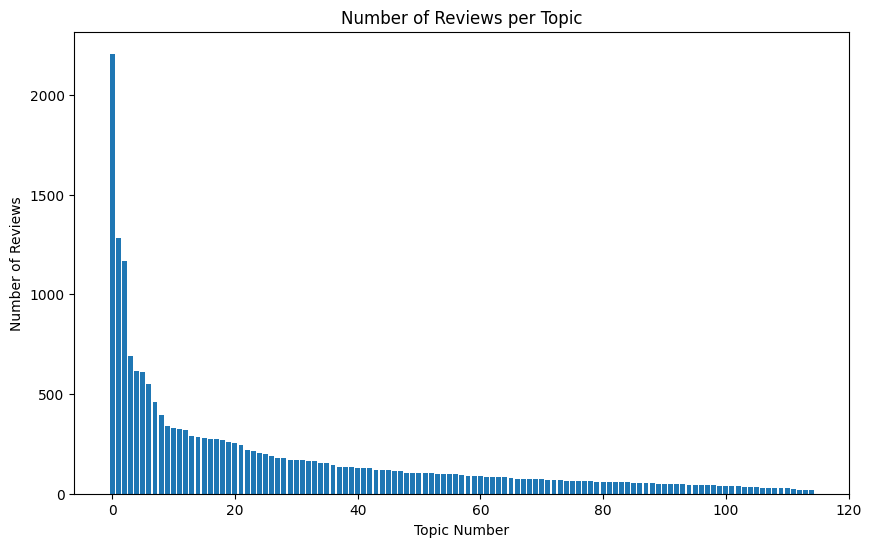

In [ ]:
# visualation des topics
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(topic_df['Topic'], topic_df['Number of Reviews'])
plt.xlabel('Topic Number')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews per Topic')
plt.show()

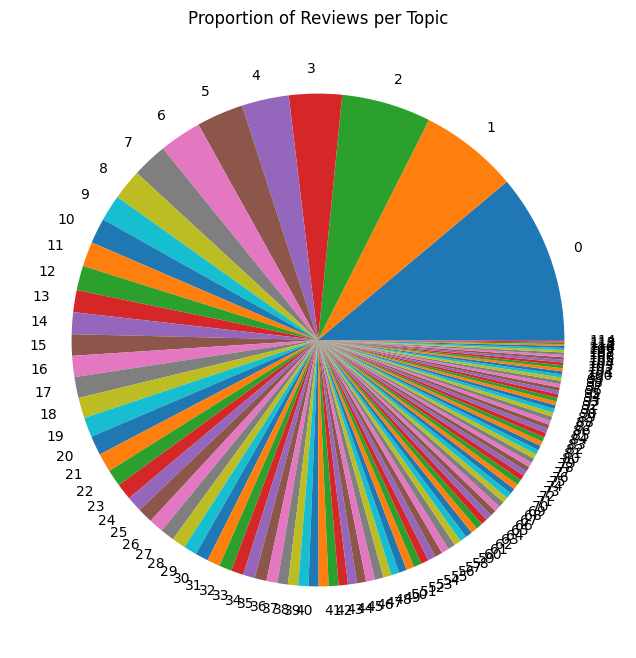

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(topic_df['Number of Reviews'], labels=topic_df['Topic'])
plt.title('Proportion of Reviews per Topic')
plt.show()

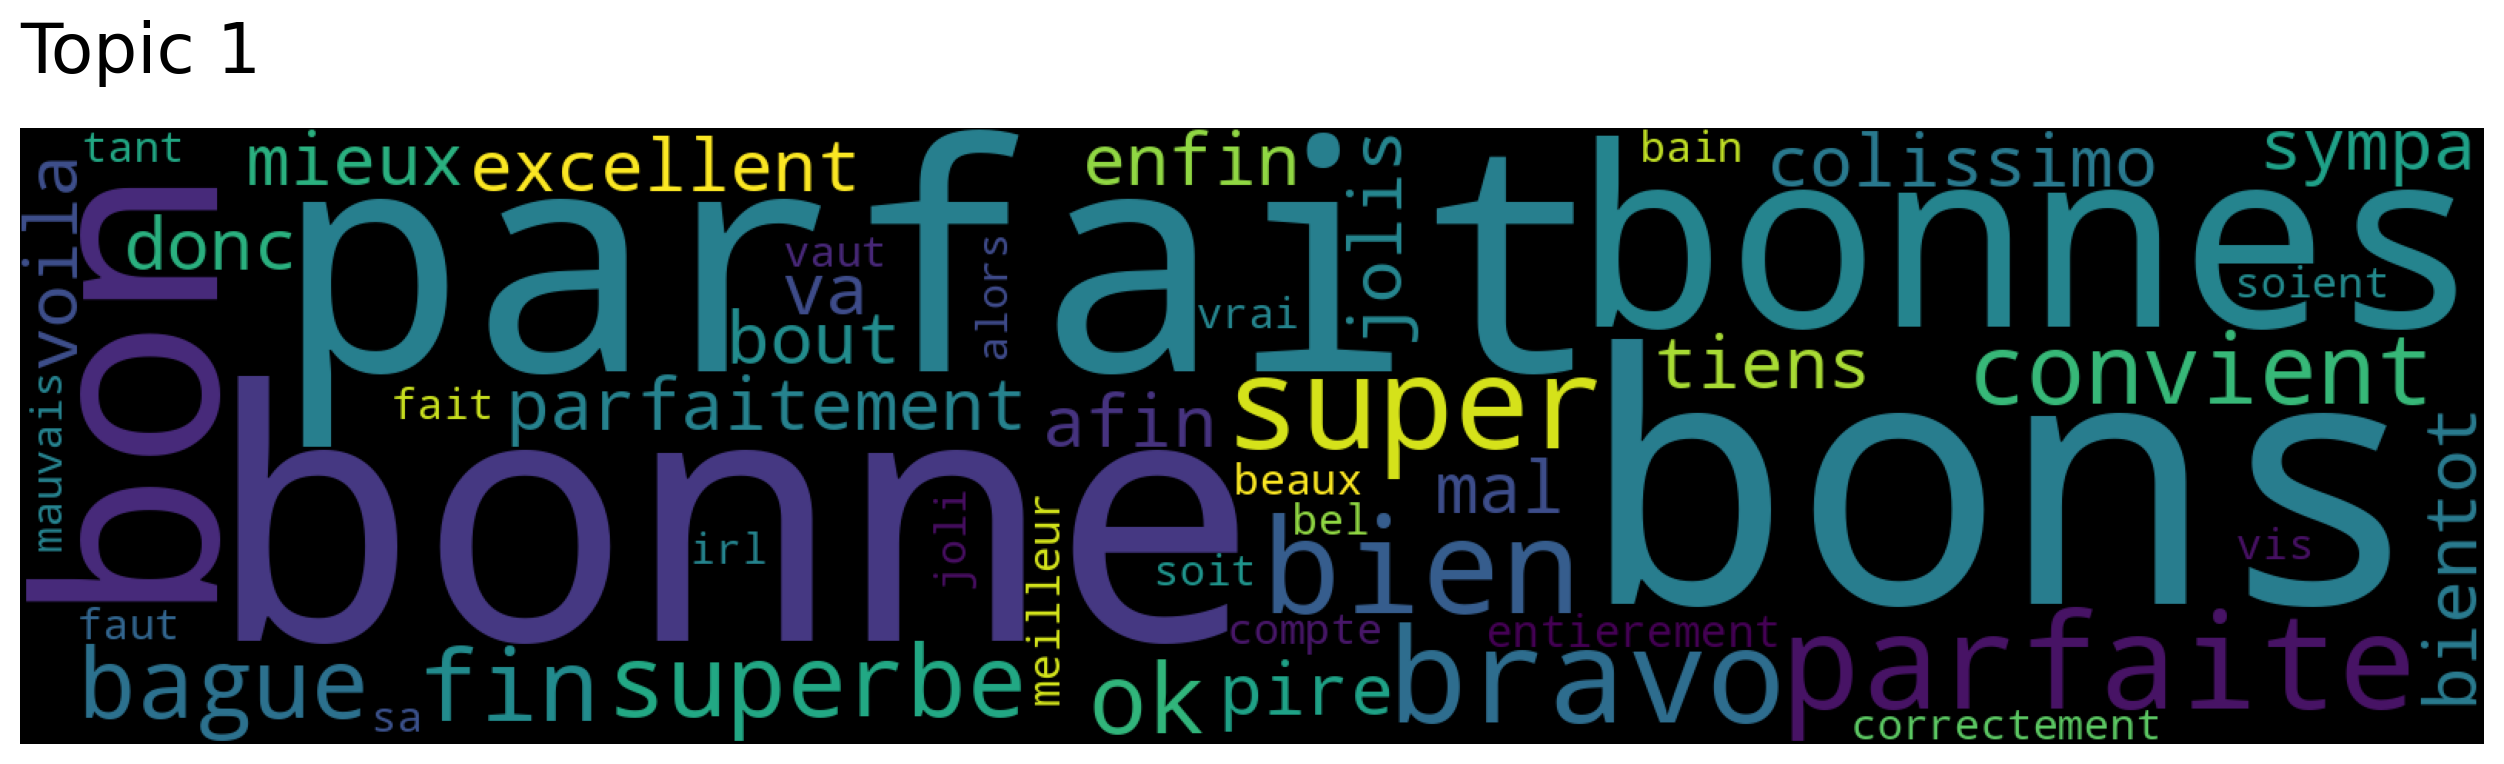

In [ ]:
# Visual evalution
#génération wordcloud pour un topic
model.generate_topic_wordcloud(1)